# Final Assignment: Part 1 - Create Visualizations using Matplotlib, Seaborn & Folium

**Automobile Sales Analysis - XYZAutomotives**

This notebook completes Tasks **1.1 to 1.9** using the historical automobile sales dataset.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

# Load the historical automobile sales dataset
df = pd.read_csv("historical_automobile_sales.csv")

# Display basic information
print("Dataset shape:", df.shape)
print("Columns:", list(df.columns))
df.head()

Matplotlib is building the font cache; this may take a moment.


Dataset shape: (528, 15)
Columns: ['Date', 'Year', 'Month', 'Recession', 'Consumer_Confidence', 'Seasonality_Weight', 'Price', 'Advertising_Expenditure', 'Competition', 'GDP', 'Growth_Rate', 'unemployment_rate', 'Automobile_Sales', 'Vehicle_Type', 'City']


,Date,Year,Month,Recession,Consumer_Confidence,Seasonality_Weight,Price,Advertising_Expenditure,Competition,GDP,Growth_Rate,unemployment_rate,Automobile_Sales,Vehicle_Type,City
0,1/31/1980,1980,Jan,1,108.24,0.50,27483.571,1558,7,60.223,0.010000,5.4,456.0,Supperminicar,Georgia
1,2/29/1980,1980,Feb,1,98.75,0.75,24308.678,3048,4,45.986,-0.309594,4.8,555.9,Supperminicar,New York
2,3/31/1980,1980,Mar,1,107.48,0.20,28238.443,3137,3,35.141,-0.308614,3.4,620.0,Mediumfamilycar,New York
3,4/30/1980,1980,Apr,1,115.01,1.00,32615.149,1653,7,45.673,0.230596,4.2,702.8,Supperminicar,Illinois
4,5/31/1980,1980,May,1,98.72,0.20,23829.233,1319,4,52.997,0.138197,5.3,770.4,Smallfamiliycar,California


## Task 1.1 - Automobile sales fluctuation from year to year

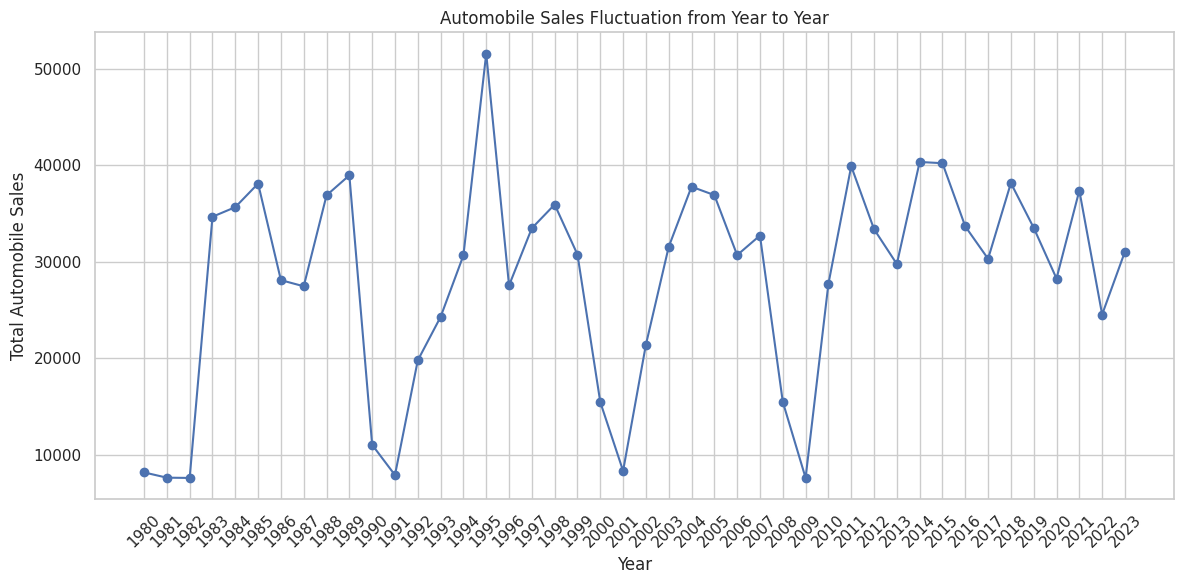

In [2]:
yearly_sales = df.groupby("Year")["Automobile_Sales"].sum()

plt.figure(figsize=(12, 6))
yearly_sales.plot(kind="line", marker="o")
plt.title("Automobile Sales Fluctuation from Year to Year")
plt.xlabel("Year")
plt.ylabel("Total Automobile Sales")
plt.xticks(yearly_sales.index, rotation=45)
plt.tight_layout()
plt.show()

**Observation:** The yearly automobile sales show noticeable fluctuations over time, with lower sales generally visible around recession periods.

## Task 1.2 - Advertising expenditure and automobile sales during non-recession periods

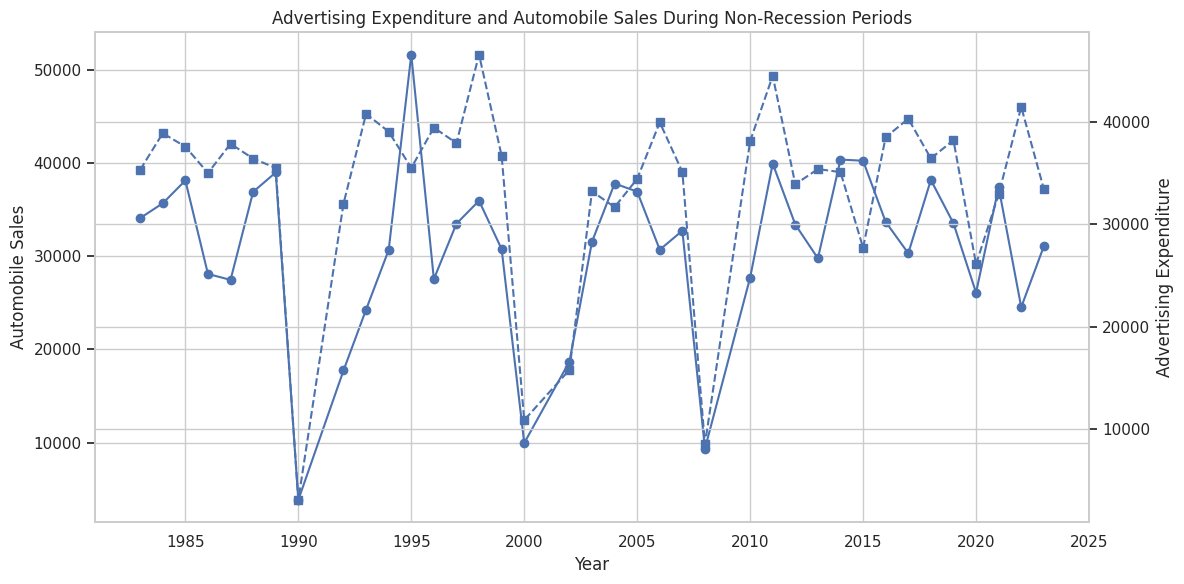

In [3]:
non_recession = df[df["Recession"] == 0].copy()
yearly_nonrec = non_recession.groupby("Year")[["Advertising_Expenditure", "Automobile_Sales"]].sum()

fig, ax1 = plt.subplots(figsize=(12, 6))
ax1.plot(yearly_nonrec.index, yearly_nonrec["Automobile_Sales"], marker="o", label="Automobile Sales")
ax1.set_xlabel("Year")
ax1.set_ylabel("Automobile Sales")

ax2 = ax1.twinx()
ax2.plot(yearly_nonrec.index, yearly_nonrec["Advertising_Expenditure"], marker="s", linestyle="--", label="Advertising Expenditure")
ax2.set_ylabel("Advertising Expenditure")

plt.title("Advertising Expenditure and Automobile Sales During Non-Recession Periods")
fig.tight_layout()
plt.show()

**Observation:** During non-recession periods, changes in advertising expenditure can be compared directly with changes in automobile sales. The chart helps identify whether increases in advertising are accompanied by higher sales.

## Task 1.3 - Sales trend by vehicle type: recession vs non-recession

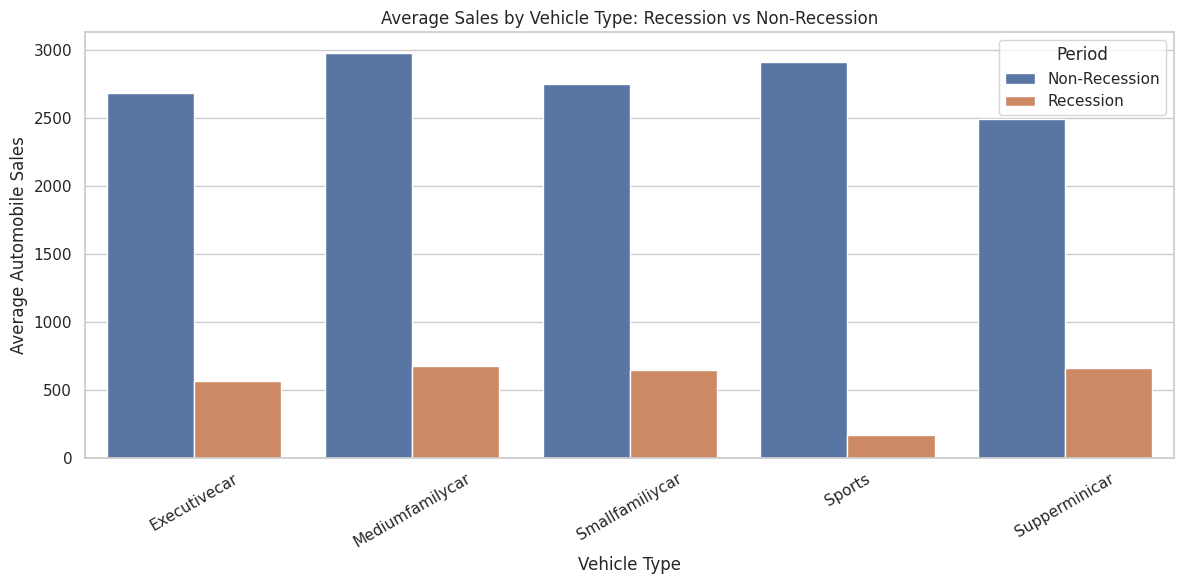

In [4]:
sales_vehicle_period = (
    df.groupby(["Recession", "Vehicle_Type"])["Automobile_Sales"]
      .mean()
      .reset_index()
)
sales_vehicle_period["Period"] = sales_vehicle_period["Recession"].map(
    {0: "Non-Recession", 1: "Recession"}
)

plt.figure(figsize=(12, 6))
sns.barplot(
    data=sales_vehicle_period,
    x="Vehicle_Type",
    y="Automobile_Sales",
    hue="Period"
)
plt.title("Average Sales by Vehicle Type: Recession vs Non-Recession")
plt.xlabel("Vehicle Type")
plt.ylabel("Average Automobile Sales")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

**Observation:** The bar chart compares the average sales of each vehicle type across recession and non-recession periods and makes differences between the two periods easy to identify.

## Task 1.4 - GDP variation during recession and non-recession periods

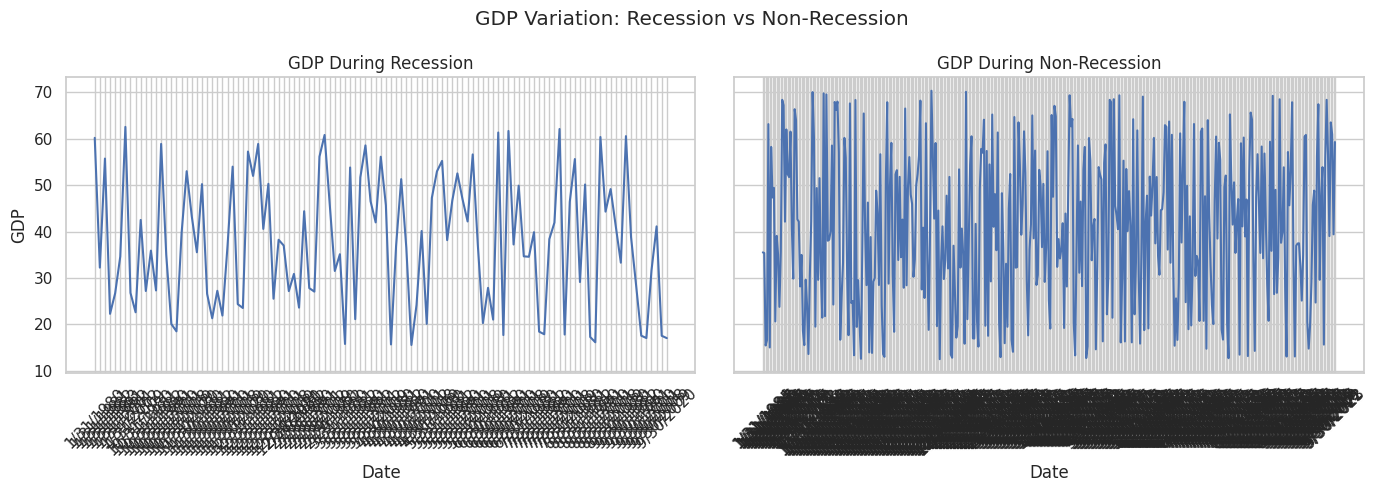

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

recession_data = df[df["Recession"] == 1].sort_values("Date")
non_recession_data = df[df["Recession"] == 0].sort_values("Date")

axes[0].plot(recession_data["Date"], recession_data["GDP"], linewidth=1.5)
axes[0].set_title("GDP During Recession")
axes[0].set_xlabel("Date")
axes[0].set_ylabel("GDP")
axes[0].tick_params(axis="x", rotation=45)

axes[1].plot(non_recession_data["Date"], non_recession_data["GDP"], linewidth=1.5)
axes[1].set_title("GDP During Non-Recession")
axes[1].set_xlabel("Date")
axes[1].tick_params(axis="x", rotation=45)

plt.suptitle("GDP Variation: Recession vs Non-Recession")
plt.tight_layout()
plt.show()

**Observation:** GDP generally behaves differently during recession and non-recession periods. The two subplots make the variation in GDP across the two economic conditions clear.

## Task 1.5 - Bubble plot: impact of seasonality on automobile sales

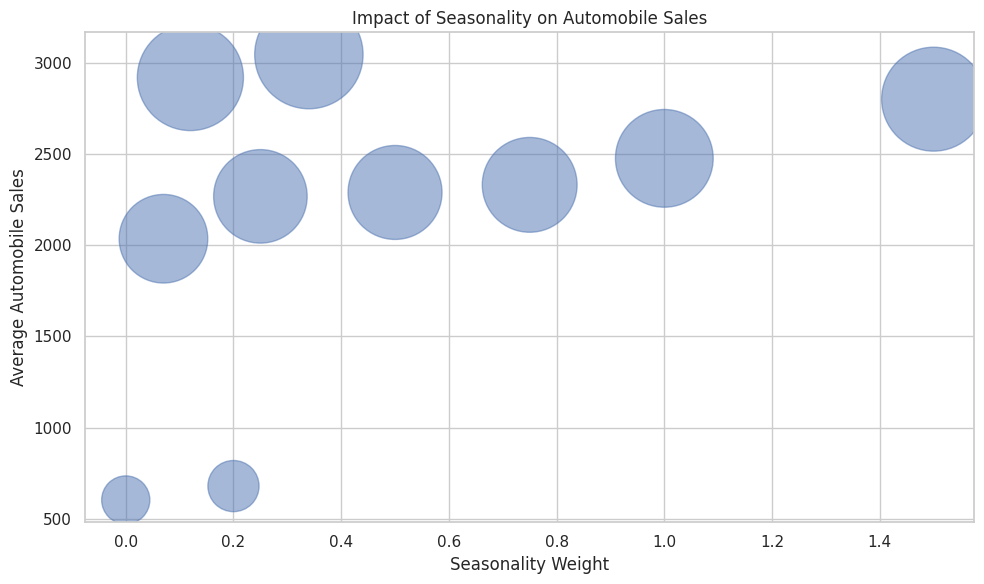

In [6]:
bubble_data = (
    df.groupby("Seasonality_Weight", as_index=False)["Automobile_Sales"]
      .mean()
      .sort_values("Seasonality_Weight")
)

plt.figure(figsize=(10, 6))
plt.scatter(
    bubble_data["Seasonality_Weight"],
    bubble_data["Automobile_Sales"],
    s=bubble_data["Automobile_Sales"] * 2,
    alpha=0.5
)
plt.title("Impact of Seasonality on Automobile Sales")
plt.xlabel("Seasonality Weight")
plt.ylabel("Average Automobile Sales")
plt.tight_layout()
plt.show()

**Observation:** The bubble sizes represent automobile sales, allowing the relationship between seasonality weight and sales volume to be visually compared.

## Task 1.6 - Correlation between average vehicle price and sales volume during recessions

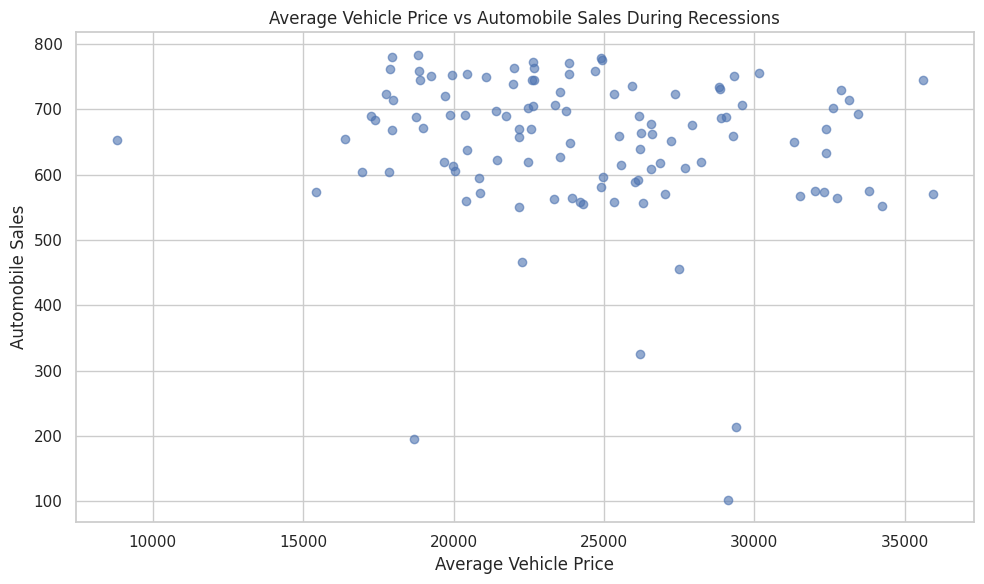

Correlation coefficient: -0.14681851201646695


In [7]:
recession_data = df[df["Recession"] == 1]

plt.figure(figsize=(10, 6))
plt.scatter(
    recession_data["Price"],
    recession_data["Automobile_Sales"],
    alpha=0.6
)
plt.title("Average Vehicle Price vs Automobile Sales During Recessions")
plt.xlabel("Average Vehicle Price")
plt.ylabel("Automobile Sales")
plt.tight_layout()
plt.show()

print("Correlation coefficient:",
      recession_data["Price"].corr(recession_data["Automobile_Sales"]))

**Observation:** The scatter plot shows the relationship between vehicle price and sales volume during recessions. The printed correlation coefficient provides a numerical measure of the strength and direction of the relationship.

## Task 1.7 - Advertising expenditure during recession and non-recession

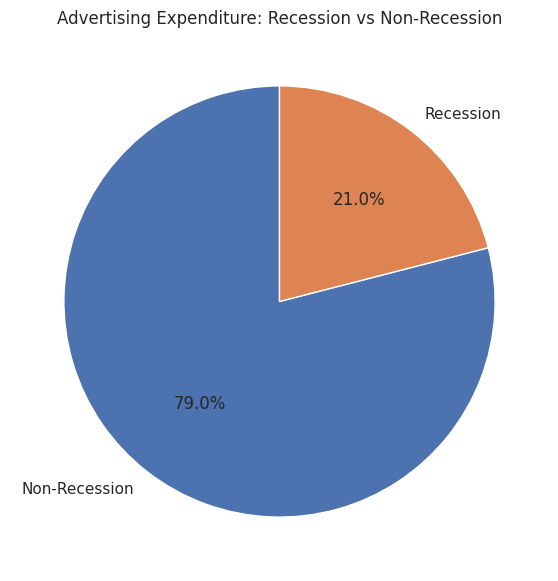

In [8]:
advertising_period = df.groupby("Recession")["Advertising_Expenditure"].sum()

plt.figure(figsize=(7, 7))
plt.pie(
    advertising_period.values,
    labels=["Non-Recession", "Recession"],
    autopct="%1.1f%%",
    startangle=90
)
plt.title("Advertising Expenditure: Recession vs Non-Recession")
plt.show()

**Observation:** The pie chart shows the proportion of total advertising expenditure allocated during recession and non-recession periods.

## Task 1.8 - Total advertising expenditure by vehicle type during recession

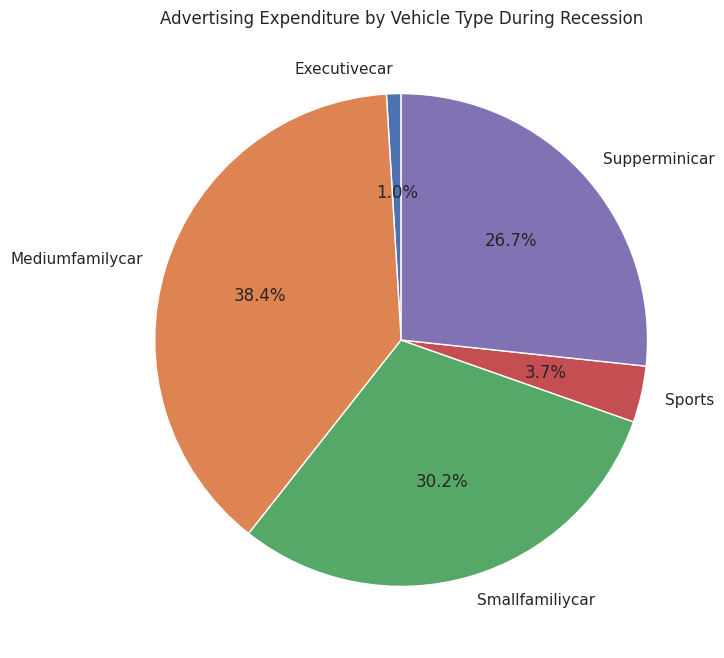

In [9]:
vehicle_ad = (
    df[df["Recession"] == 1]
    .groupby("Vehicle_Type")["Advertising_Expenditure"]
    .sum()
)

plt.figure(figsize=(8, 8))
plt.pie(
    vehicle_ad.values,
    labels=vehicle_ad.index,
    autopct="%1.1f%%",
    startangle=90
)
plt.title("Advertising Expenditure by Vehicle Type During Recession")
plt.show()

**Observation:** The pie chart compares the share of recession-period advertising expenditure across different vehicle types.

## Task 1.9 - Effect of unemployment rate on vehicle type and sales during recession

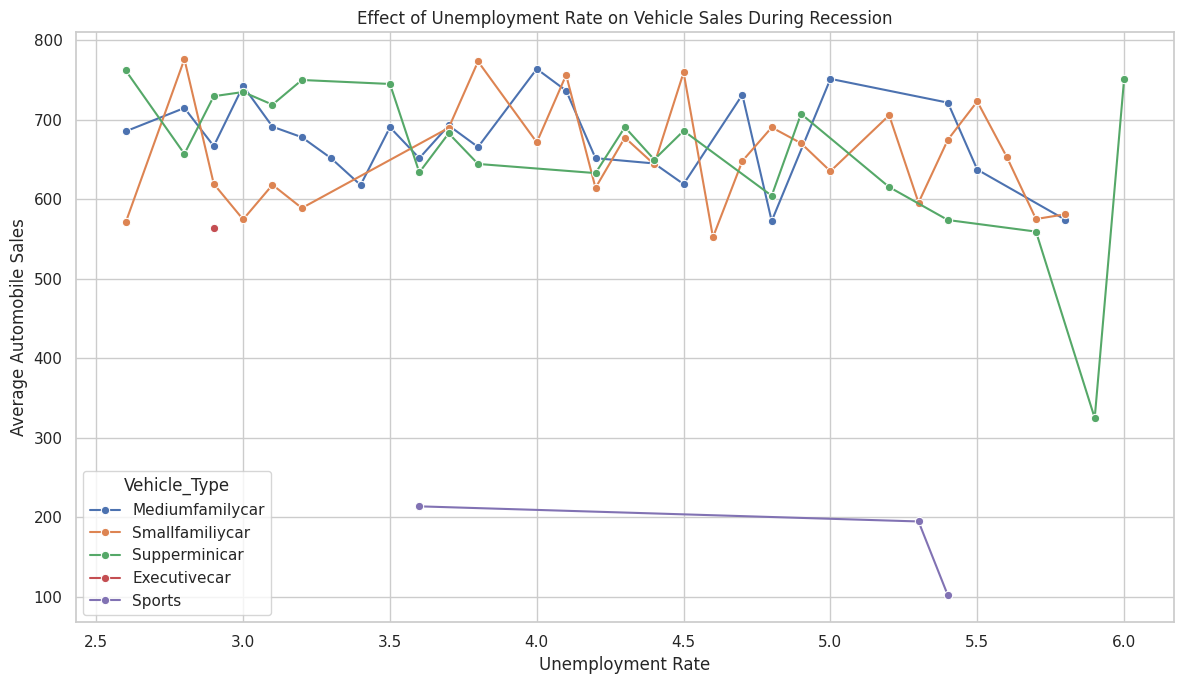

In [10]:
unemployment_sales = (
    df[df["Recession"] == 1]
    .groupby(["unemployment_rate", "Vehicle_Type"])["Automobile_Sales"]
    .mean()
    .reset_index()
    .sort_values("unemployment_rate")
)

plt.figure(figsize=(12, 7))
sns.lineplot(
    data=unemployment_sales,
    x="unemployment_rate",
    y="Automobile_Sales",
    hue="Vehicle_Type",
    marker="o"
)
plt.title("Effect of Unemployment Rate on Vehicle Sales During Recession")
plt.xlabel("Unemployment Rate")
plt.ylabel("Average Automobile Sales")
plt.tight_layout()
plt.show()

**Observation:** The line chart compares automobile sales across vehicle types at different unemployment rates during recession periods. It helps show how changes in unemployment are associated with sales for different vehicle categories.